In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
df = pd.read_csv("/insurance.csv")

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [65]:
pd.set_option("display.float_format","{:.2f}".format)

In [66]:
df.shape

(1340, 10)

In [67]:
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
df.isna().sum()

,0
Id,0
age,5
gender,0
bmi,0
bloodpressure,0
diabetic,0
children,0
smoker,0
region,3
claim,0


# There are 8 duplicated values so we delete them.

In [70]:
df.dropna(inplace=True)

In [71]:
df.shape

(1332, 10)

In [72]:
df.describe()

,Id,age,bmi,bloodpressure,children,claim
count,1332.00,1332.00,1332.00,1332.00,1332.00,1332.00
mean,674.47,38.09,30.66,94.19,1.10,13325.25
std,384.70,11.11,6.12,11.45,1.21,12109.62
min,1.00,18.00,16.00,80.00,0.00,1121.87
25%,341.75,29.00,26.20,86.00,0.00,4760.16
50%,674.50,38.00,30.35,92.00,1.00,9412.97
75%,1007.25,47.00,34.73,99.00,2.00,16781.33
max,1340.00,60.00,53.10,140.00,5.00,63770.43


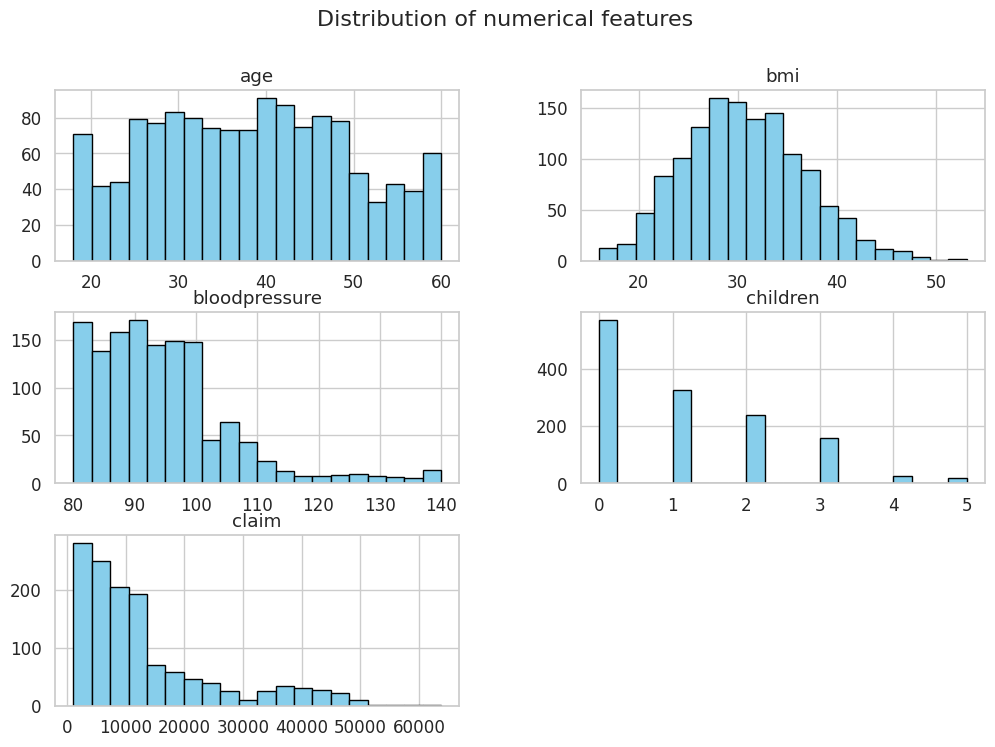

In [73]:
numeric_cols = ["age","bmi","bloodpressure","children","claim"]
df[numeric_cols].hist(bins=20,figsize=(12,8),color="skyblue",edgecolor="black")
plt.suptitle("Distribution of numerical features",fontsize=16)
plt.show()

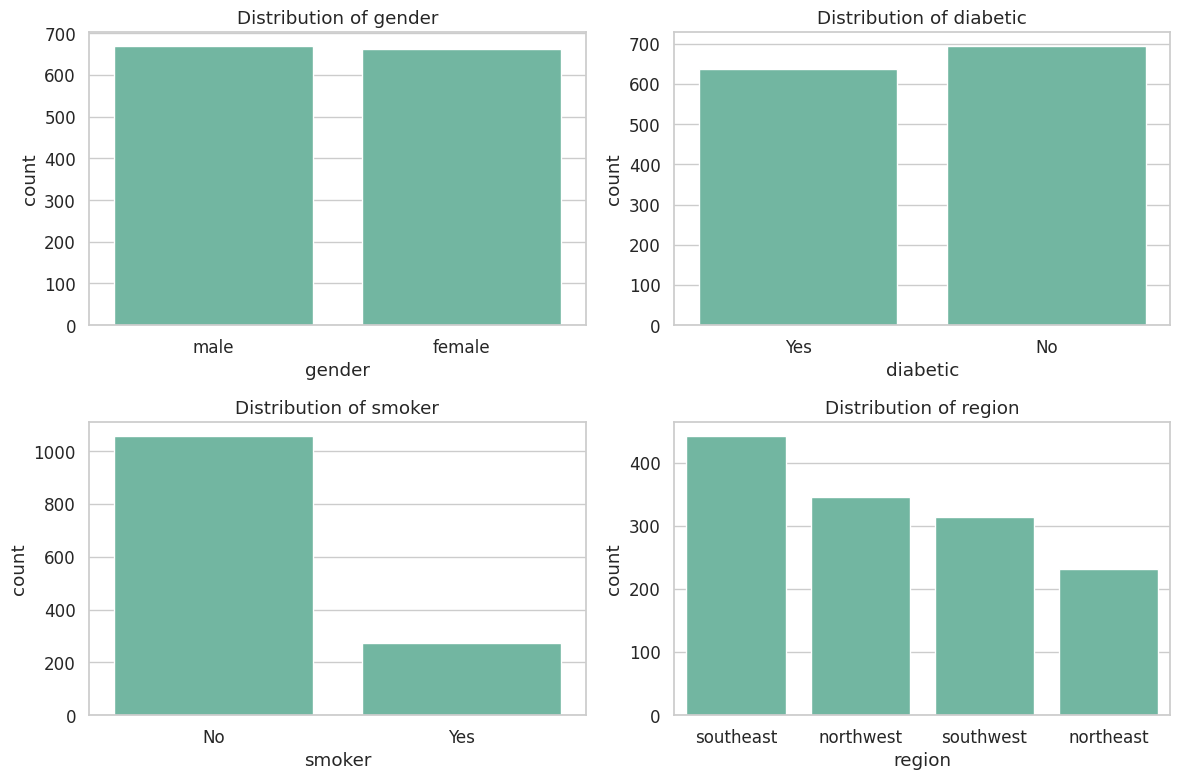

In [74]:
cat_cols=["gender","diabetic","smoker","region"]

plt.figure(figsize=(12,8))

for i, col in enumerate(cat_cols,1):
  plt.subplot(2,2,i)
  sns.countplot(data=df,x=col)
  plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [75]:
df.groupby(["gender","smoker"])["claim"].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

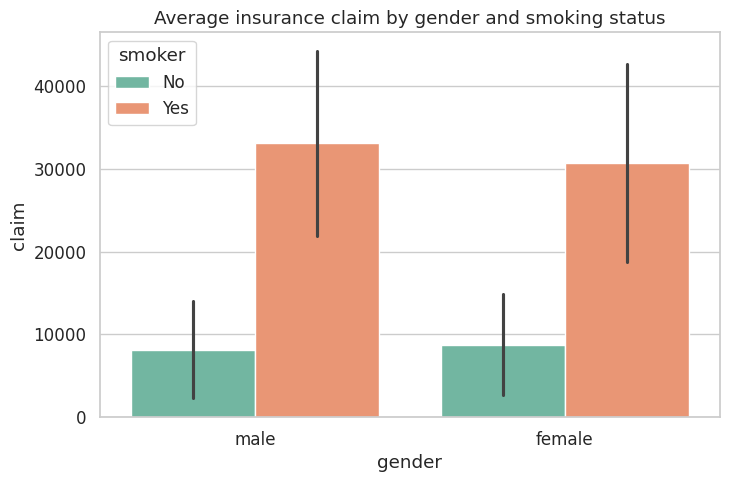

In [76]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="gender",y="claim",hue="smoker",estimator="mean",errorbar="sd")
plt.title("Average insurance claim by gender and smoking status")
plt.show()

In [77]:
pivot_region_diabetic = df.groupby(["region","diabetic"])["claim"].mean().unstack()

In [78]:
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


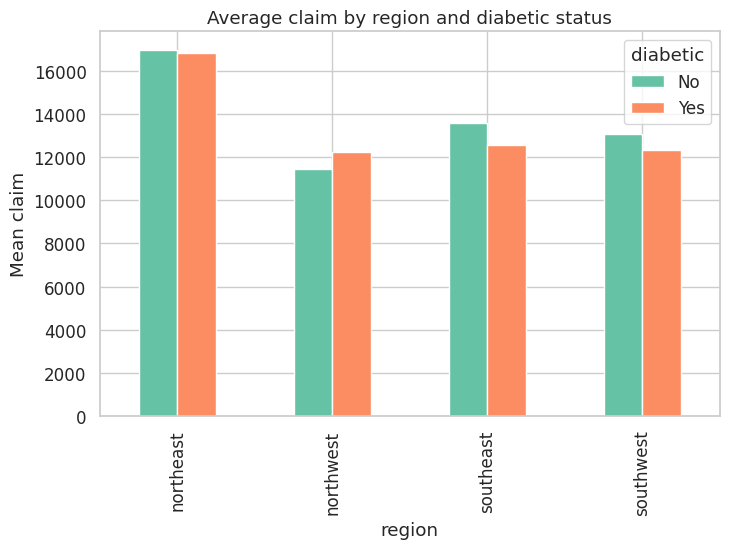

In [79]:
pivot_region_diabetic.plot(kind="bar",figsize=(8,5))
plt.title("Average claim by region and diabetic status")
plt.ylabel("Mean claim")
plt.show()

In [80]:
pivot_table=pd.pivot_table(df, values="claim", index="region", columns="smoker", aggfunc="mean")
pivot_table

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [81]:
pivot_table=pd.pivot_table(df, values="claim", index="children", columns="diabetic", aggfunc="mean")
pivot_table

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


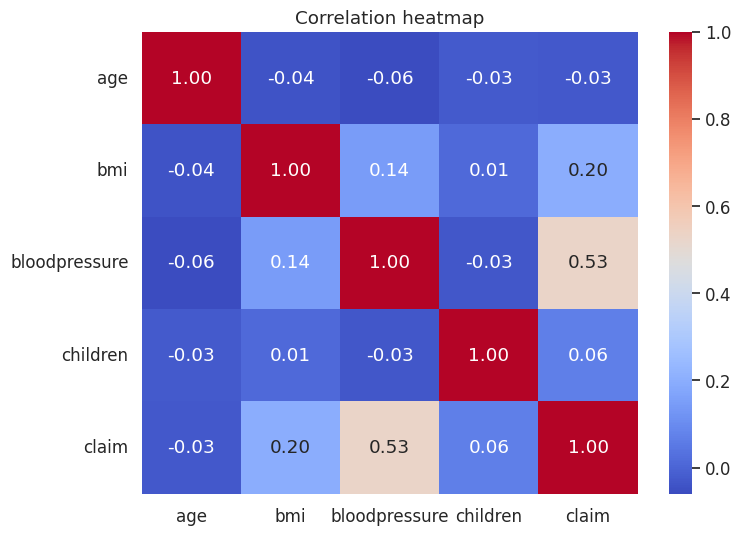

In [82]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

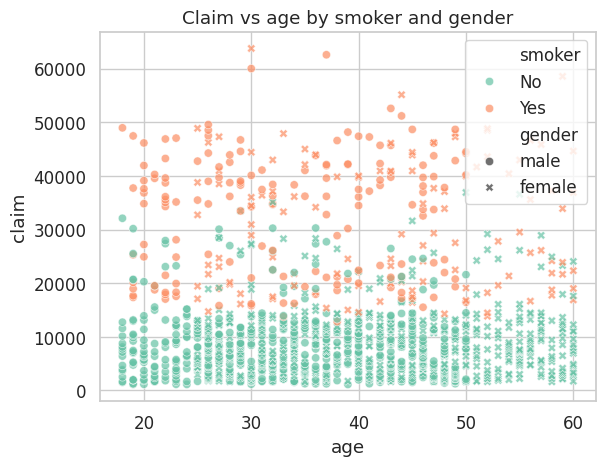

In [83]:
sns.scatterplot(data=df,x="age",y="claim",hue="smoker",style="gender",alpha=0.7)
plt.title("Claim vs age by smoker and gender")
plt.show()

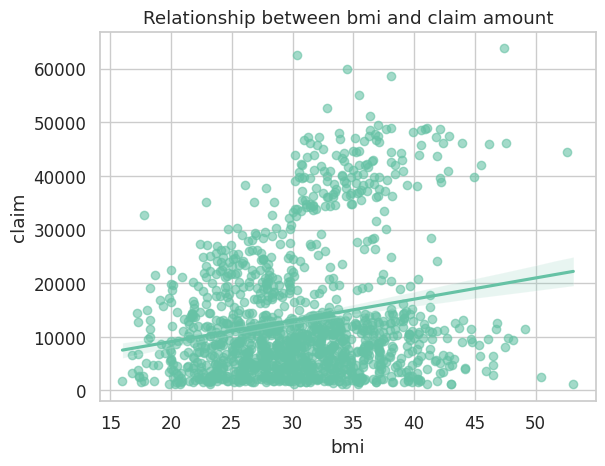

In [84]:
sns.regplot(data=df,x="bmi",y="claim",scatter_kws={"alpha":0.6})
plt.title("Relationship between bmi and claim amount")
plt.show()

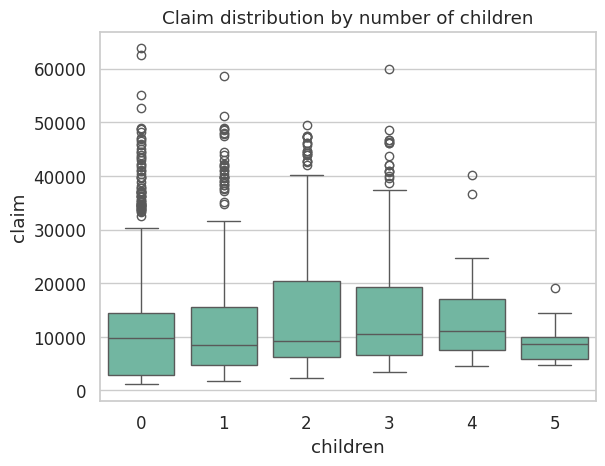

In [85]:
sns.boxplot(data=df,x="children",y="claim")
plt.title("Claim distribution by number of children")
plt.show()

In [86]:
df["age_group"]= pd.cut(df["age"],bins=[0,18,30,45,60,100],labels=["<18","18-30","31-45","46-60","60+"])

In [87]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,31-45
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,18-30
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,18-30
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,18-30
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,18-30
...,...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40,31-45
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07,46-60
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40,18-30
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87,31-45


In [88]:
df["age_group"].value_counts()

,count
age_group,
31-45,553
46-60,383
18-30,380
<18,16
60+,0


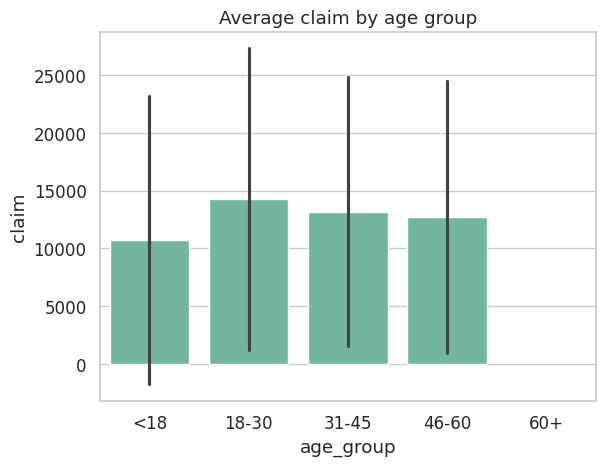

In [89]:
sns.barplot(data=df,x="age_group",y="claim",estimator="mean",errorbar="sd")
plt.title("Average claim by age group")
plt.show()

In [90]:
df["bmi_category"]=pd.cut(df["bmi"],bins=[0,18.5,24.9,29.9,100],labels=["underweight","normal","overweight","obese"])
df["bmi_category"].value_counts()

,count
bmi_category,
obese,702
overweight,387
normal,222
underweight,21


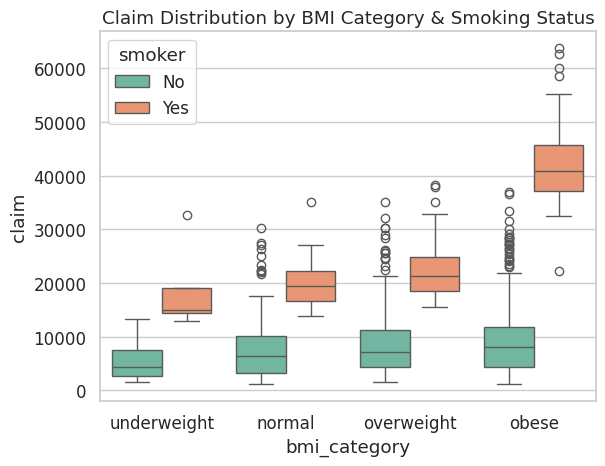

In [91]:
sns.boxplot(data = df, x="bmi_category", y="claim", hue= "smoker")
plt.title("Claim Distribution by BMI Category & Smoking Status")
plt. show()

In [92]:
region_stats=df.groupby("region").agg(
    smoker_rate=("smoker",lambda x:(x=="Yes").mean()*100),
    mean_claim=("claim","mean")
).reset_index()

region_stats

,region,smoker_rate,mean_claim
0,northeast,29.00,16889.04
1,northwest,16.81,11794.22
2,southeast,20.59,13085.50
3,southwest,18.47,12723.13


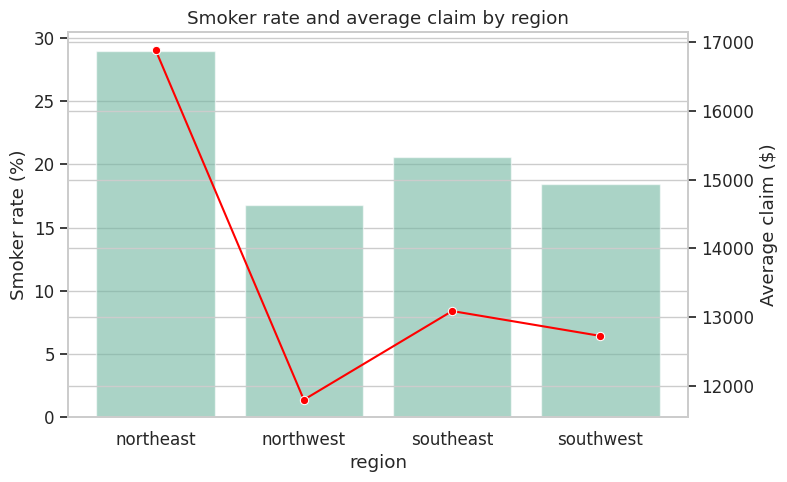

In [93]:
fig, ax1 = plt.subplots(figsize=(8,5))
sns.barplot(data=region_stats,x="region",y="smoker_rate",ax=ax1,alpha=0.6)
ax2=ax1.twinx()
sns.lineplot(data=region_stats,x="region",y="mean_claim",color="red",marker="o",ax=ax2)
ax1.set_ylabel("Smoker rate (%)")
ax2.set_ylabel("Average claim ($)")
plt.title("Smoker rate and average claim by region")
plt.show()

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
import joblib

In [95]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [96]:
x = df[["age","gender","bmi","bloodpressure","diabetic","children","smoker"]]
y = df["claim"]

In [97]:
cat_cols=["gender","diabetic","smoker"]
label_encoders={}

In [98]:
from google.colab import files

for col in cat_cols:
  le=LabelEncoder()
  x[col]=le.fit_transform(x[col])
  label_encoders[col]=le

  filename = f"label_encoder_{col}.pkl"
  joblib.dump(le, filename)
  # This will trigger a browser download for each file
  files.download(filename)

/tmp/ipykernel_749/3574204449.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[col]=le.fit_transform(x[col])


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_749/3574204449.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[col]=le.fit_transform(x[col])


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_749/3574204449.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[col]=le.fit_transform(x[col])


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [99]:
x

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,1,23.20,91,1,0,0
1,24.00,1,30.10,87,0,0,0
7,19.00,1,41.10,100,0,0,0
8,20.00,1,43.00,86,0,0,0
9,30.00,1,53.10,97,0,0,0
...,...,...,...,...,...,...,...
1335,44.00,0,35.50,88,1,0,1
1336,59.00,0,38.10,120,0,1,1
1337,30.00,1,34.50,91,1,3,1
1338,37.00,1,30.40,106,0,0,1


In [100]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

In [101]:
num_cols=["age","bmi","bloodpressure","children"]
scaler=StandardScaler()

In [102]:
x_train[num_cols]=scaler.fit_transform(x_train[num_cols])
x_test[num_cols]=scaler.transform(x_test[num_cols])

In [103]:
joblib.dump(scaler,"scaler.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [104]:
print(x_train.shape,y_train.shape)

(1065, 7) (1065,)


In [105]:
print(x_test.shape,y_test.shape)

(267, 7) (267,)


In [106]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [107]:
def evaluate_model(model, x_train, y_train, x_test, y_test):
  y_pred=model.predict(x_test)
  r2=r2_score(y_test,y_pred)
  mae=mean_absolute_error(y_test,y_pred)
  rmse=np.sqrt(mean_squared_error(y_test,y_pred))
  return {"R2":r2,"MAE":mae,"RMSE":rmse}

In [108]:
results={}

In [115]:
lr=LinearRegression()
lr.fit(x_train,y_train)
results["Linear Regression"] = evaluate_model(lr, x_train, y_train, x_test, y_test)
print("Linear Regression model trained")

best_poly_model=None
best_poly_score= -np.inf

for degree in [2,3]:
  poly=PolynomialFeatures(degree=degree)
  x_train_poly=poly.fit_transform(x_train)
  x_test_poly=poly.transform(x_test)

  poly_lr=LinearRegression()
  poly_lr.fit(x_train_poly,y_train)

  score=poly_lr.score(x_test_poly,y_test)

  if score>best_poly_score:
    best_poly_score=score
    best_poly_model=(degree,poly,poly_lr)

degree,poly,poly_lr=best_poly_model

results[f"Polynomial regression (deg={degree})"]=evaluate_model(poly_lr, poly.fit_transform(x_train), y_train, poly.transform(x_test), y_test)

print("polynomial regression models are trained")

rf=RandomForestRegressor()

rf_params={
    "n_estimators":[100,200],
    "max_depth":[None,10,20],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

rf_grid=GridSearchCV(rf,rf_params,cv=3,scoring="r2",n_jobs=-1,verbose=0)
rf_grid.fit(x_train,y_train)
best_rf=rf_grid.best_estimator_

results["Random Forest"]=evaluate_model(best_rf, x_train, y_train, x_test, y_test)

print("Random Forest training is completed, best parameters:", rf_grid.best_params_)

svr=SVR()

svr_params={
    "kernel":["rbf","poly","linear"],
    "C":[1,10,50],
    "epsilon":[0.1,0.2,0.5],
    "degree":[2,3]
}

svr_grid=GridSearchCV(svr,svr_params,cv=3,scoring="r2",n_jobs=-1,verbose=0)
svr_grid.fit(x_train,y_train)

best_svr=svr_grid.best_estimator_

results["SVR"]=evaluate_model(best_svr, x_train, y_train, x_test, y_test)

print("SVR training is completed, best parameters:", svr_grid.best_params_)

xgb=XGBRegressor(objective="reg:squarederror")

xgb_params={
    "n_estimators":[100,200],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.05,0.1],
    "subsample":[0.8,1.0]
}

xgb_grid=GridSearchCV(xgb,xgb_params,cv=3,scoring="r2",n_jobs=-1,verbose=0)
xgb_grid.fit(x_train,y_train)
best_xgb=xgb_grid.best_estimator_

results["XGBoost"]=evaluate_model(best_xgb, x_train, y_train, x_test, y_test)

print("XGBoost training is completed, best parameters:", xgb_grid.best_params_)
print(results)


Linear Regression model trained
polynomial regression models are trained
Random Forest training is completed, best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
SVR training is completed, best parameters: {'C': 50, 'degree': 2, 'epsilon': 0.5, 'kernel': 'linear'}
XGBoost training is completed, best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
{'Linear Regression': {'R2': 0.6569318013476498, 'MAE': 5414.049811523619, 'RMSE': np.float64(7105.461385346494)}, 'Polynomial regression (deg=3)': {'R2': 0.7517700225807227, 'MAE': 4527.033327589161, 'RMSE': np.float64(6044.065558942362)}, 'Random Forest': {'R2': 0.7993636466102998, 'MAE': 3981.897106830407, 'RMSE': np.float64(5433.840237883934)}, 'SVR': {'R2': 0.4747430381878409, 'MAE': 5908.138244555406, 'RMSE': np.float64(8792.005704022744)}, 'XGBoost': {'R2': 0.8020816924254258, 'MAE': 4018.3107184866567, 'RMSE': np.float64(5396.908273655659)}}


In [116]:
results

{'Linear Regression': {'R2': 0.6569318013476498,
  'MAE': 5414.049811523619,
  'RMSE': np.float64(7105.461385346494)},
 'Polynomial regression (deg=3)': {'R2': 0.7517700225807227,
  'MAE': 4527.033327589161,
  'RMSE': np.float64(6044.065558942362)},
 'Random Forest': {'R2': 0.7993636466102998,
  'MAE': 3981.897106830407,
  'RMSE': np.float64(5433.840237883934)},
 'SVR': {'R2': 0.4747430381878409,
  'MAE': 5908.138244555406,
  'RMSE': np.float64(8792.005704022744)},
 'XGBoost': {'R2': 0.8020816924254258,
  'MAE': 4018.3107184866567,
  'RMSE': np.float64(5396.908273655659)}}

In [117]:
results_df = pd. DataFrame(results).T.sort_values (by= "R2", ascending= False)
results_df

,R2,MAE,RMSE
XGBoost,0.80,4018.31,5396.91
Random Forest,0.80,3981.90,5433.84
Polynomial regression (deg=3),0.75,4527.03,6044.07
Linear Regression,0.66,5414.05,7105.46
SVR,0.47,5908.14,8792.01


In [119]:
models = {
  "Linear Regression": lr,
  "Polynomial Regression": poly_lr,
  "Random Forest": best_rf,
  "SVR": best_svr,
  "XGBoost": best_xgb
}

In [120]:
best_r2=results_df["R2"].max()

In [121]:
best_r2

0.8020816924254258

In [122]:
top_model=results_df[results_df["R2"]==best_r2]

In [123]:
top_model

,R2,MAE,RMSE
XGBoost,0.80,4018.31,5396.91


In [124]:
best_model=models[top_model.index[0]]
best_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [125]:
joblib.dump(best_model,"best_model.pkl")
files.download("best_model.pkl")
print(f"Best model selected: {top_model.index[0]}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Best model selected: XGBoost
